<a href="https://colab.research.google.com/github/rsyadipras/PCVK_Ganjil2026/blob/main/Week6_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Risky Adi Prasetya - 244107020153 - TI-3E - 21
# Week6 — Filter Spasial: LPF, HPF, Point/Line/Edge Detection

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im



---


# Konvolusi tanpa library
Fungsi konvolusi dibuat manual, tidak memakai cv2.filter2D atau fungsi konvolusi OpenCV lainnya.

Parameter: image, kernel, stride, padding.

In [28]:
def convolution2d(image, kernel, stride=1, padding=0):
    img = image.astype(np.float64)
    kh, kw = kernel.shape
    if padding > 0:
        img = np.pad(img, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    H, W = img.shape
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1
    out = np.zeros((out_h, out_w), dtype=np.float64)
    for y in range(out_h):
        for x in range(out_w):
            y0, x0 = y * stride, x * stride
            region = img[y0:y0 + kh, x0:x0 + kw]
            out[y, x] = np.sum(region * kernel)   # perkalian elemen + jumlahkan
    return np.clip(out, 0, 255).astype(np.uint8)

### Load citra dan ubah ke grayscale

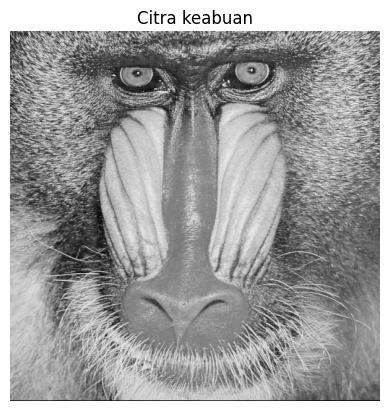

Ukuran citra: (512, 512)


In [29]:
img = cv.imread('/content/drive/MyDrive/PCVK2026/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap='gray')
plt.title('Citra keabuan')
plt.axis('off')
plt.show()

print('Ukuran citra:', img_gray.shape)

In [30]:
kernel_sharpen = np.array([[ 0, -1,  0],
                            [-1,  5, -1],
                            [ 0, -1,  0]], dtype=np.float64)

kernel_emboss  = np.array([[-2, -1,  0],
                            [-1,  1,  1],
                            [ 0,  1,  2]], dtype=np.float64)

kernel_left_sobel = np.array([[ 1, 0, -1],
                               [ 2, 0, -2],
                               [ 1, 0, -1]], dtype=np.float64)

# kernel Laplacian 3x3 (kernel canny)
kernel_laplacian = np.array([[-1, -1, -1],
                              [-1,  8, -1],
                              [-1, -1, -1]], dtype=np.float64)

# Gaussian 21x21 dibangun dari cv.getGaussianKernel
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian21 = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0, 255,   0, ..., 255, 255,   0],
       [  0, 255, 179, ..., 249, 218,   0],
       ...,
       [  0, 255, 255, ..., 159, 183,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
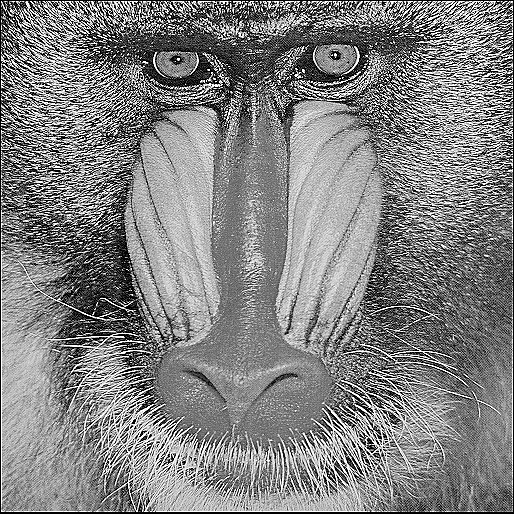

In [31]:
convolution2d(img_gray, kernel_sharpen, 1, 2)

### Penerapan Image Filter
Average filter, low pass filter, dan high pass filter, sharpen, emboss, Left Sobel Edge Detection, canny edge detection, 21x21 gaussian Blur

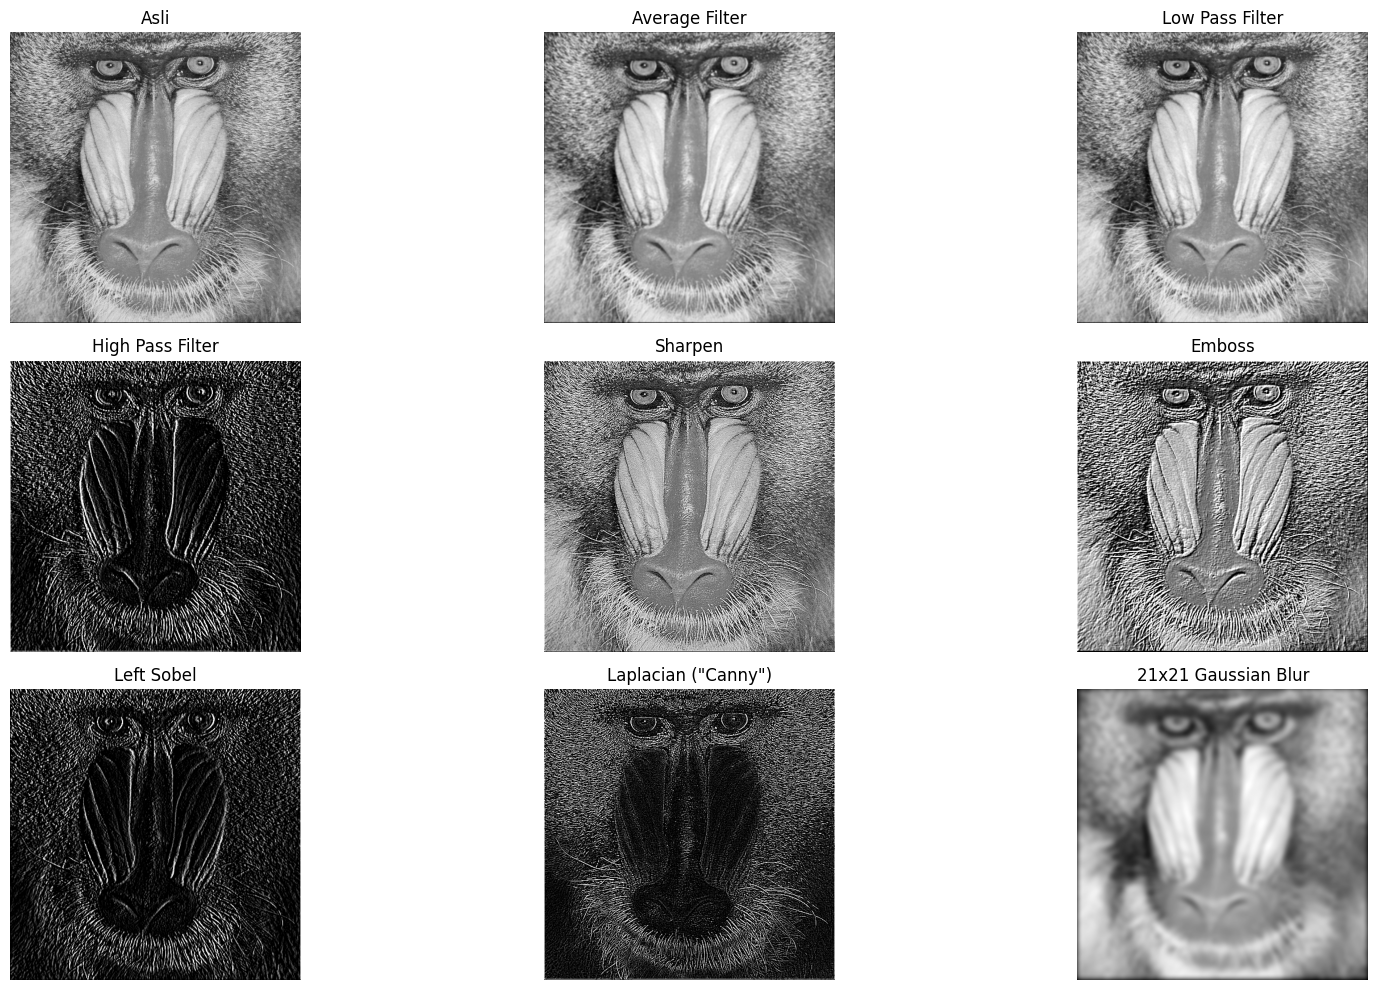

In [32]:
kernel_average = np.ones((3,3), dtype=np.float64) / 9
kernel_lpf     = np.array([[1,1,1],[1,4,1],[1,1,1]], dtype=np.float64) / 12
kernel_hpf     = np.array([[-1,0,1],[-1,0,3],[-3,0,1]], dtype=np.float64)

hasil_average  = convolution2d(img_gray, kernel_average,   stride=1, padding=1)
hasil_lpf      = convolution2d(img_gray, kernel_lpf,       stride=1, padding=1)
hasil_hpf      = convolution2d(img_gray, kernel_hpf,       stride=1, padding=1)
hasil_sharpen  = convolution2d(img_gray, kernel_sharpen,   stride=1, padding=1)
hasil_emboss   = convolution2d(img_gray, kernel_emboss,    stride=1, padding=1)
hasil_lsobel   = convolution2d(img_gray, kernel_left_sobel,stride=1, padding=1)
hasil_laplace  = convolution2d(img_gray, kernel_laplacian, stride=1, padding=1)
hasil_gauss21  = convolution2d(img_gray, kernel_gaussian21,stride=1, padding=10)

semua = [img_gray, hasil_average, hasil_lpf, hasil_hpf,
         hasil_sharpen, hasil_emboss, hasil_lsobel, hasil_laplace, hasil_gauss21]
judul = ['Asli', 'Average Filter', 'Low Pass Filter', 'High Pass Filter',
         'Sharpen', 'Emboss', 'Left Sobel', 'Laplacian ("Canny")', '21x21 Gaussian Blur']

plt.figure(figsize=(18, 10))
for i, (im_, t) in enumerate(zip(semua, judul), 1):
    plt.subplot(3, 3, i)
    plt.imshow(im_, cmap='gray')
    plt.title(t)
    plt.axis('off')
plt.tight_layout()
plt.show()

# FILTER LIBRARY DAN FILTER MODERN

In [33]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (image, title) in enumerate(zip(images, titles)):
        if len(image.shape) == 2:   # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(image, cmap='gray')
        else:                        # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.show()

### Percobaan 1 — Gaussian, Sharpen, Canny via `cv2.filter2D`/`cv2.Canny`

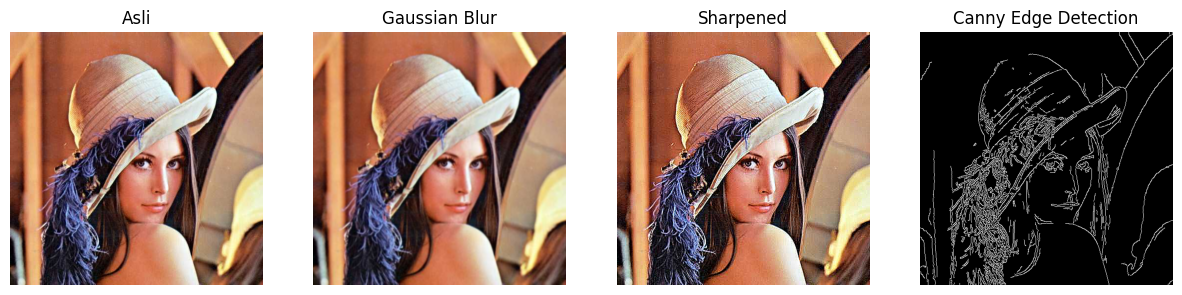

In [34]:
img = cv.imread('/content/drive/MyDrive/PCVK2026/Images/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur   = cv.GaussianBlur(img, (7, 7), 1)
edges  = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                   ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

### Percobaan 2 — Bilateral Filter dan Edge Preserving (Guided) Filter

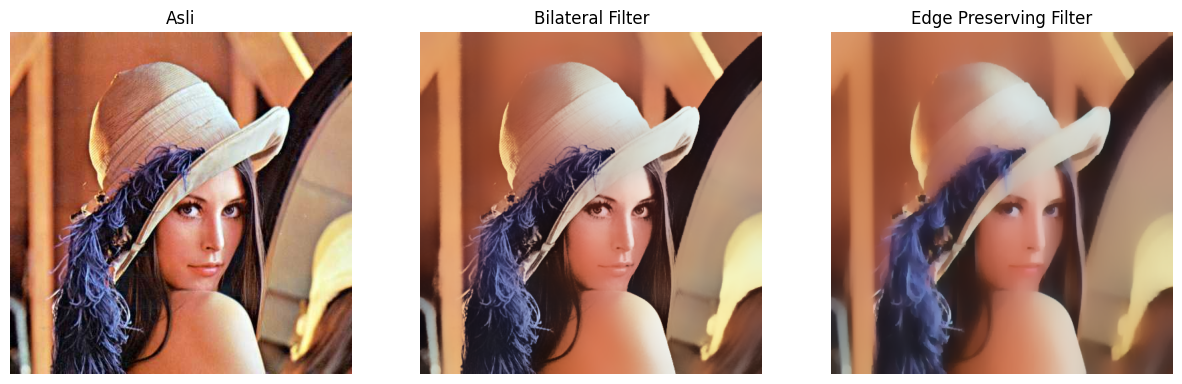

In [35]:
bilateral     = cv.bilateralFilter(img, 50, 100, 100)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                   ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

### Percobaan 3 — Filtering pada CNN (Feature Map)

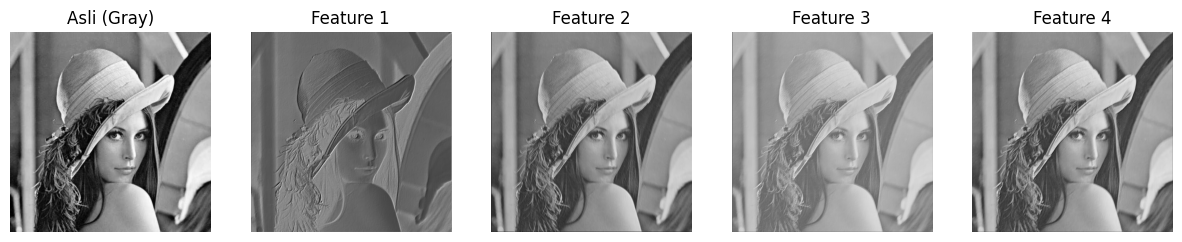

In [36]:
# Filter Feature Map yang digunakan pada CNN, lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps,
                   ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

### Percobaan 4 — Beauty Filter dan Old/Vintage Filter

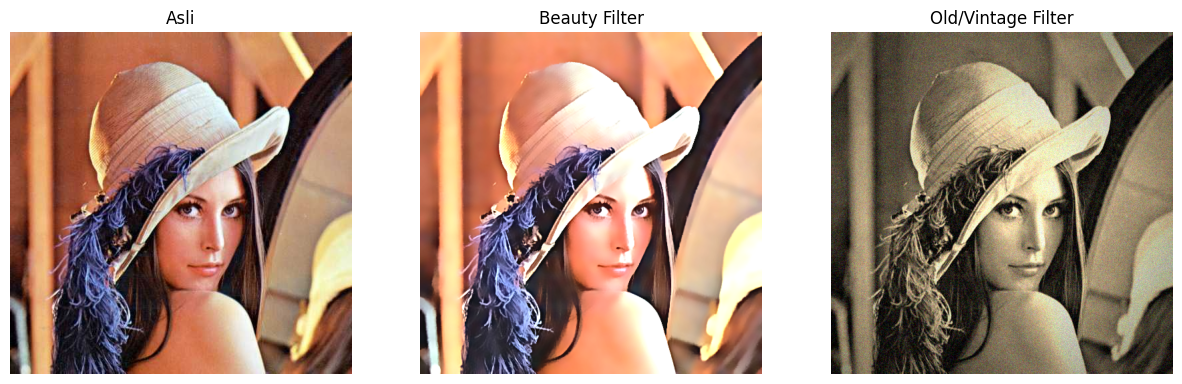

In [37]:
# ======================
# 1. Beauty Filter
# ======================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened_b = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2   # contrast
beta  = 15    # brightness
beauty = cv.convertScaleAbs(sharpened_b, alpha=alpha, beta=beta)

# ======================
# 2. Old/Vintage Filter
# ======================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                          [0.349, 0.686, 0.168],
                          [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel_v = kernel_y * kernel_x.T
mask = kernel_v / kernel_v.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

### Percobaan 5 — Filter Anime/Cartoon

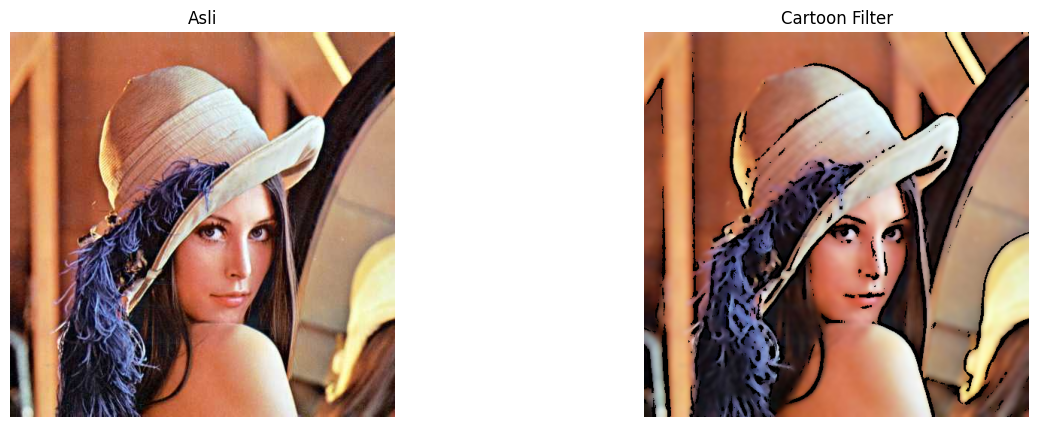

In [38]:
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray_c = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur_c = cv.medianBlur(gray_c, 7)
edges_c = cv.adaptiveThreshold(gray_blur_c, 255,
                                cv.ADAPTIVE_THRESH_MEAN_C,
                                cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color_c = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color_c, color_c, mask=edges_c)

show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

### Percobaan 6 — Filter Malam (Night)

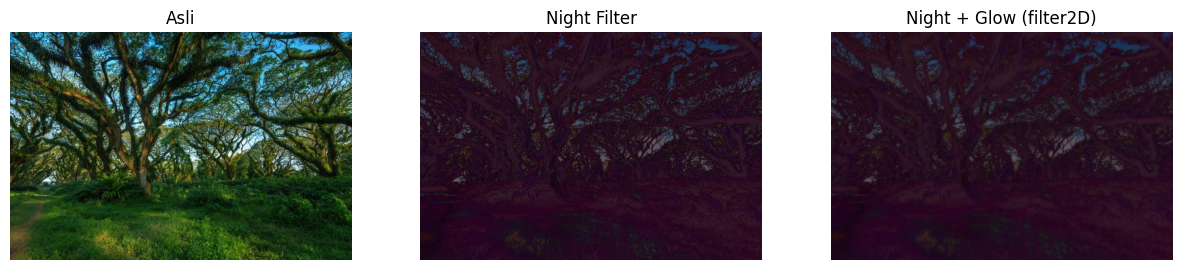

In [39]:
# Night Filter
img = cv.imread('/content/drive/MyDrive/PCVK2026/Images/djawatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))   # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel_glow = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel_glow)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                   ["Asli", "Night Filter", "Night + Glow (filter2D)"])

### Percobaan 7 — Filter Suasana Pagi dan Kabut

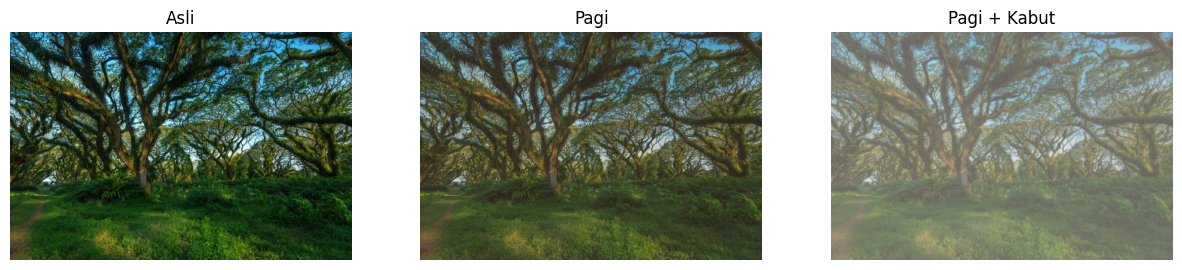

In [40]:
# ==========================
# Step 1: Kurangi kontras & cerahkan
# ==========================
alpha = 0.9   # contrast
beta  = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ==========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ==========================
warm_tint = np.full_like(soft, (40, 70, 120))   # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ==========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ==========================
kernel_haze = cv.getGaussianKernel(3, 3)
kernel_haze = kernel_haze @ kernel_haze.T
kabut = cv.filter2D(pagi, -1, kernel_haze)

# Tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut], ["Asli", "Pagi", "Pagi + Kabut"])

---
# TUGAS PRAKTIKUM

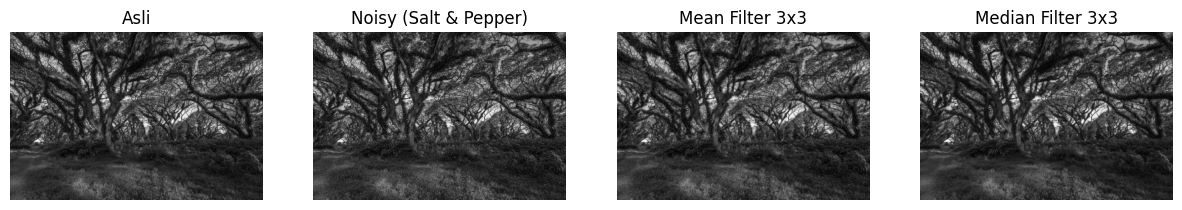

In [41]:
# Tugas 1 - Mean Filter vs Median Filter pada noise Salt and Pepper
def tambah_salt_pepper(gray, amount=0.02):
    # amount = proporsi piksel yang diberi noise sehingga setengah jadi putih, setengah jadi hitam
    out = gray.copy()
    n = int(amount * gray.size)
    ys = np.random.randint(0, gray.shape[0], n)
    xs = np.random.randint(0, gray.shape[1], n)
    out[ys[:n // 2], xs[:n // 2]] = 255     # salt
    out[ys[n // 2:], xs[n // 2:]] = 0       # pepper
    return out

noisy = tambah_salt_pepper(img_gray, amount=0.02)
mean_filtered   = cv.blur(noisy, (3, 3))
median_filtered = cv.medianBlur(noisy, 3)

show_side_by_side([img_gray, noisy, mean_filtered, median_filtered],
                   ["Asli", "Noisy (Salt & Pepper)", "Mean Filter 3x3", "Median Filter 3x3"])

Analisis:

- Mean filter menghitung rata-rata nilai tetangga, sehingga nilai ekstrem (0 atau 255) pada piksel ber-noise tetap ikut dirata-rata dan "menyebar" ke piksel di sekitarnya. Hasilnya noise memang berkurang tapi tersamar menjadi noda buram, dan citra jadi keseluruhan lebih blur.

- Median filter mengambil nilai tengah dari jendela tetangga, karena piksel salt/pepper adalah outlier ekstrem, nilai tersebut hampir selalu tersingkir dari posisi median dan diganti nilai piksel normal di sekitarnya — sehingga noise hilang bersih tanpa mengaburkan tepi/detail citra yang tidak ber-noise.

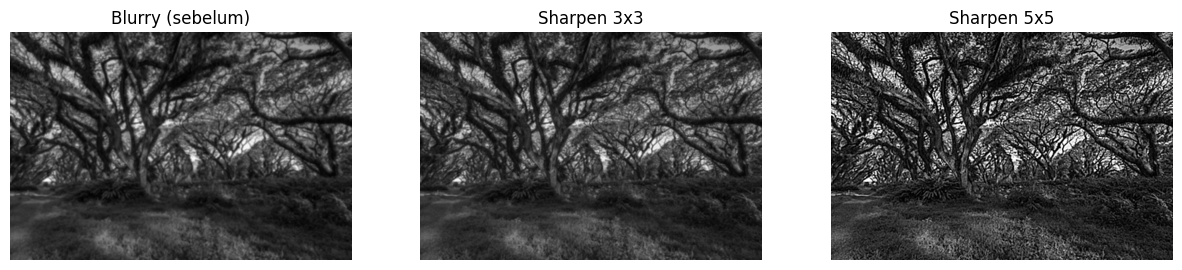

In [42]:
## Tugas 2 - Sharpening Kernel 3x3 vs 5x5
blurry = cv.GaussianBlur(img_gray, (7, 7), 2)   # citra sedikit buram untuk diuji

kernel_sharpen_3x3 = np.array([[ 0, -1,  0],
                                [-1,  5, -1],
                                [ 0, -1,  0]])

kernel_sharpen_5x5 = np.array([[ 0,  0, -1,  0,  0],
                                [ 0, -1, -2, -1,  0],
                                [-1, -2, 17, -2, -1],
                                [ 0, -1, -2, -1,  0],
                                [ 0,  0, -1,  0,  0]])

hasil_3x3 = cv.filter2D(blurry, -1, kernel_sharpen_3x3)
hasil_5x5 = cv.filter2D(blurry, -1, kernel_sharpen_5x5)

show_side_by_side([blurry, hasil_3x3, hasil_5x5],
                   ["Blurry (sebelum)", "Sharpen 3x3", "Sharpen 5x5"])

Evaluasi:
- Kernel 3x3 menghasilkan penajaman yang lebih ringan dan natural, tepi menjadi lebih jelas tanpa banyak memunculkan noise/artefak, karena jangkauan tetangga
yang dilibatkan kecil.

- Kernel 5x5 melibatkan lebih banyak piksel tetangga sehingga efek penajamannya jauh lebih kuat dan agresif, tepi tampak sangat tajam, namun area dengan tekstur halus mulai memunculkan noise/ringing yang tidak natural.

- Kesimpulan: kernel 3x3 lebih optimal untuk penggunaan sehari-hari karena hasilnya lebih seimbang; kernel 5x5 baru cocok dipakai bila memang dibutuhkan efek penajaman yang sangat kuat dan noise tambahan bisa ditoleransi.

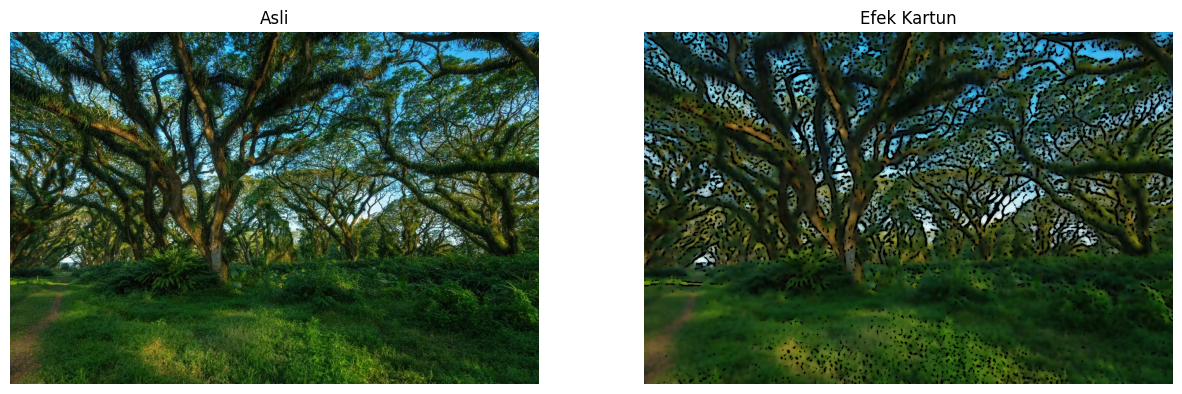

In [43]:
# Tugas 3 - Filter Kartun Sederhana (fungsi `kartun(image)`)

def kartun(image):
    # Penghalusan warna agar area warna menjadi rata (Bilateral Filter)
    color_flat = cv.bilateralFilter(image, d=9, sigmaColor=250, sigmaSpace=250)

    # Deteksi garis tepi (Adaptive Thresholding dari citra grayscale)
    gray_k = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_k = cv.medianBlur(gray_k, 5)
    edges_k = cv.adaptiveThreshold(gray_k, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

    # Gabungkan warna rata dengan garis tepi (operasi logika AND)
    hasil = cv.bitwise_and(color_flat, color_flat, mask=edges_k)
    return hasil

hasil_kartun = kartun(img)
show_side_by_side([img, hasil_kartun], ["Asli", "Efek Kartun"])